In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import cdmprof

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
# Load halo data
halos = cdmprof.load_from_folder("/Users/rstiskalek/Projects/CDMprofile/data/test_halos")
print(f"Loaded {halos.n_halos} halos")

In [3]:
# Bin all halos (each halo gets its own rmin/rmax)
binned = halos.bin(nbin=30)
print(f"Binned data shape: {binned['bin_counts'].shape}")
print(f"bin_positions shape: {binned['bin_positions'].shape} (per halo)")

Binned data shape: (225, 30)
bin_positions shape: (225, 30) (per halo)


In [ ]:
# Compile a fitter for a density profile
# expr = "(a0 * (1 + x)**a1)**-1"
# expr = "1 / (x * (1 + x)**2)"
# expr = "exp(1/(a0 + x))"
expr = "exp(a0/(x - exp(sqrt(x))))"

fitter = cdmprof.compile_fitter(expr)
print(f"Expression: {expr}")
print(f"Number of parameters: {fitter.nparams} (Rs + {fitter.nfree} free)")

# Generate numpy function: rho_func(r, Rs, a0, a1, ...)
parser = cdmprof.SympyParser()
rho_func = parser.to_numpy(expr)
print(f"Generated numpy function with signature: rho_func(r, Rs, {', '.join(f'a{i}' for i in range(fitter.nfree))})")

In [10]:
# Fit all halos with multiple restarts and early stopping
results = []
for i in tqdm(range(halos.n_halos), desc="Fitting"):
    result = fitter.fit_with_restarts(
        binned['bin_counts'][i],
        binned['bin_positions'][i],
        binned['rmin'][i],
        binned['rmax'][i],
        max_restarts=100,
        nconv_required=5,
        conv_rtol=1e-3,
        # conv_atol=0.5,
        # maxeval=2000,
        # a_lower=-500,
        # a_upper=500,
        seed=42 + i,
    )
    result['halo_id'] = binned['halo_ids'][i]
    results.append(result)

print(f"\nFitted {len(results)} halos")

Fitting: 100%|██████████| 225/225 [00:00<00:00, 516.93it/s]


Fitted 225 halos


In [11]:
# Summary statistics
# Filter out failed fits (params is None)
valid_results = [r for r in results if r['params'] is not None]
print(f"Valid fits: {len(valid_results)}/{len(results)}")

if len(valid_results) > 0:
    losses = np.array([r['loss'] for r in valid_results])
    converged = np.array([r['converged'] for r in valid_results])
    confirmed = np.array([r['confirmed'] for r in valid_results])
    params = np.array([r['params'] for r in valid_results])
    neval = np.array([r['neval'] for r in valid_results])
    nrestart_used = np.array([r['nrestart_used'] for r in valid_results])
    nconv = np.array([r['nconv'] for r in valid_results])

    print(f"Converged: {converged.sum()}/{len(converged)}")
    print(f"Confirmed (converged to same min >= 5 times): {confirmed.sum()}/{len(confirmed)}")
    print(f"Loss: min={losses.min():.2f}, median={np.median(losses):.2f}, max={losses.max():.2f}")
    print(f"Total evals per halo: mean={neval.mean():.0f}, max={neval.max()}")
    print(f"Restarts used: mean={nrestart_used.mean():.1f}, max={nrestart_used.max()}")

    print(f"\nParameter ranges:")
    print(f"  Rs: [{params[:,0].min():.3f}, {params[:,0].max():.3f}]")
    for i in range(fitter.nfree):
        print(f"  a{i}: [{params[:,i+1].min():.3f}, {params[:,i+1].max():.3f}]")
else:
    print("No valid fits!")

Valid fits: 225/225
Converged: 225/225
Confirmed (converged to same min >= 5 times): 225/225
Loss: min=293536.09, median=4251047.96, max=180344566.57
Total evals per halo: mean=510, max=2709
Restarts used: mean=9.3, max=60

Parameter ranges:
  Rs: [124.024, 13673.916]
  a0: [-45.679, -16.178]


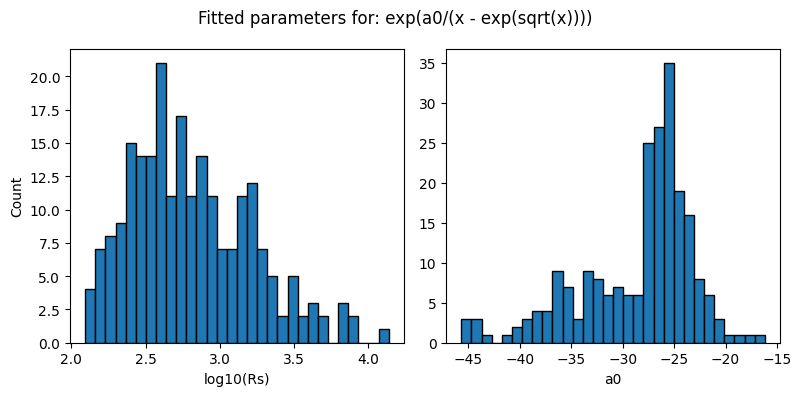

In [12]:
# Plot parameter distributions
ncols = 1 + fitter.nfree
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
if ncols == 1:
    axes = [axes]

axes[0].hist(np.log10(params[:, 0]), bins=30, edgecolor='black')
axes[0].set_xlabel('log10(Rs)')
axes[0].set_ylabel('Count')

for i in range(fitter.nfree):
    axes[i + 1].hist(params[:, i + 1], bins=30, edgecolor='black')
    axes[i + 1].set_xlabel(f'a{i}')

plt.suptitle(f"Fitted parameters for: {expr}")
plt.tight_layout()
plt.show()

Plotting Halo 1 with Rs=13673.92, a0=-38.27
Plotting Halo 281 with Rs=396.95, a0=-21.86
Plotting Halo 489 with Rs=3004.87, a0=-36.21
Plotting Halo 1300 with Rs=508.06, a0=-26.40
Plotting Halo 3250 with Rs=338.64, a0=-27.75
Plotting Halo 7783 with Rs=1408.73, a0=-35.54


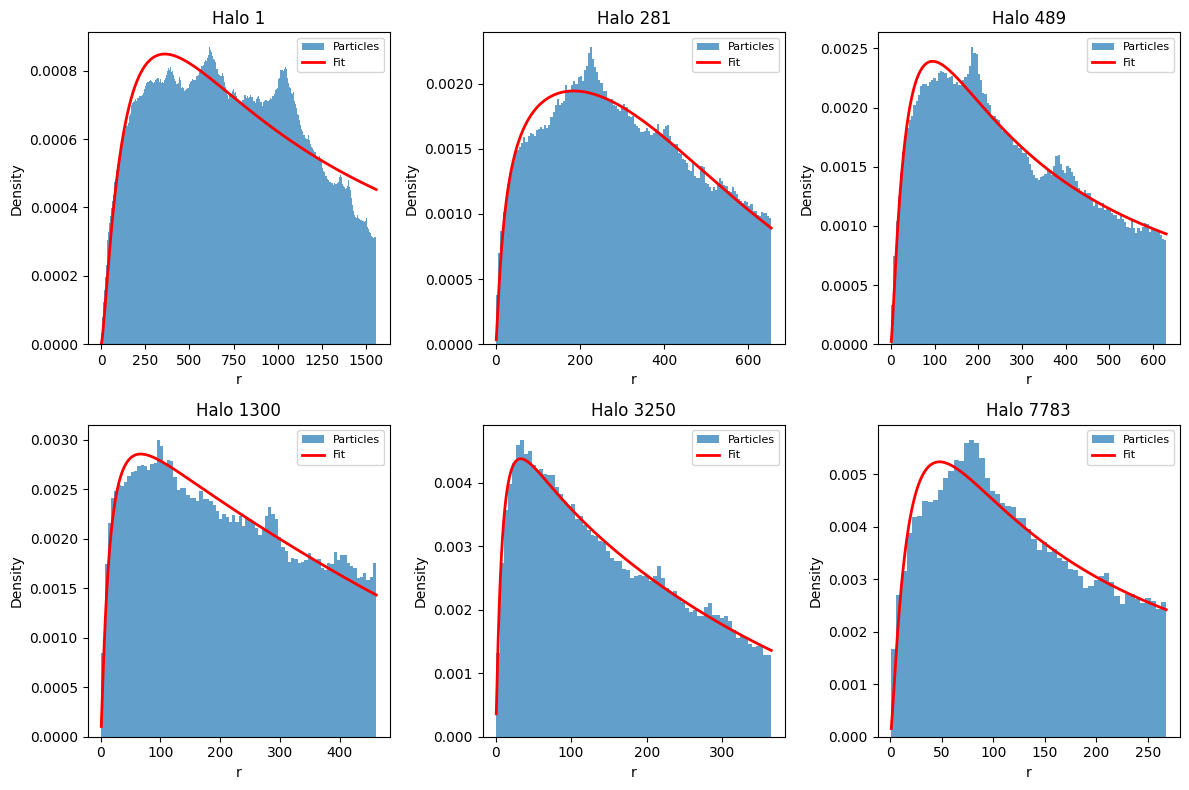

In [15]:
# Plot a few example fits with raw particle histograms
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Use only valid results (params is not None)
valid_indices = [i for i, r in enumerate(results) if r['params'] is not None]

for i, ax in enumerate(axes):
    idx = valid_indices[i * (len(valid_indices) // 6)]  # Sample evenly from valid
    res = results[idx]
    halo_id = res['halo_id']
    
    # Raw particle radii from loader
    radii = halos[halo_id]
    
    # Fitted model parameters
    positions = binned['bin_positions'][idx]
    fit_params = res['params']  # [Rs, a0, a1, ...]
    
    # Print parameters
    param_str = f"Rs={fit_params[0]:.2f}"
    for j in range(fitter.nfree):
        param_str += f", a{j}={fit_params[j+1]:.2f}"
    print(f"Plotting Halo {halo_id} with {param_str}")
    
    # Evaluate fitted profile using auto-generated numpy function
    r = np.linspace(radii.min(), radii.max(), 1000)
    rho_fit = rho_func(r, *fit_params)
    
    # Plot histogram of raw radii
    ax.hist(radii, bins="auto", density=True, alpha=0.7, label='Particles')
    
    # Overlay fitted density (scaled)
    rho_scaled = rho_fit * r**2
    rho_scaled = rho_scaled / np.trapezoid(rho_scaled, r)
    ax.plot(r, rho_scaled, 'r-', lw=2, label='Fit')
    
    ax.set_xlabel('r')
    ax.set_ylabel('Density')
    ax.set_title(f"Halo {halo_id}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()